# Data Preparation and cleaning:-


🔴 Shape of dataset 🔴 (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



🔴 Dataset Info 🔴
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

🔴 Statistical Summary 🔴


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



🔴 Missing values per column 🔴


...

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


🔴 Shape of customer-level dataset 🔴 (4338, 6)


,CustomerID,NumInvoices,TotalQuantity,TotalSpending,LastPurchaseDate,Recency
0,12346,1,74215,77183.60,2011-01-18 10:01:00,326
1,12347,7,2458,4310.00,2011-12-07 15:52:00,2
2,12348,4,2341,1797.24,2011-09-25 13:13:00,75
3,12349,1,631,1757.55,2011-11-21 09:51:00,19
4,12350,1,197,334.40,2011-02-02 16:01:00,310


,Recency,NumInvoices,TotalQuantity,TotalSpending
0,326,1,74215,77183.60
1,2,7,2458,4310.00
2,75,4,2341,1797.24
3,19,1,631,1757.55
4,310,1,197,334.40



🔴 Feature Correlation Matrix 🔴


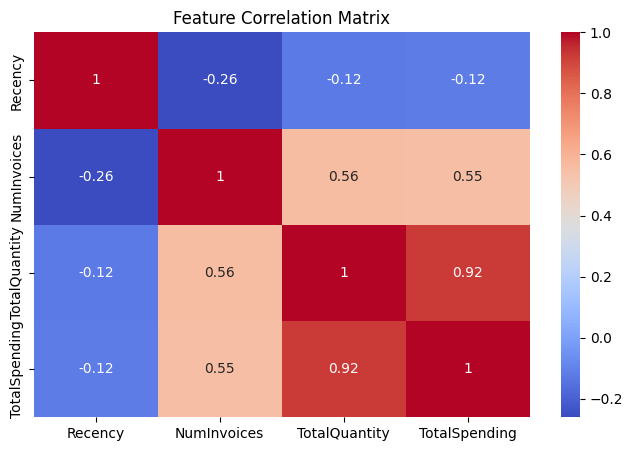

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sys.version

# E-commerce Data Preparation and Feature Engineering

## 1. Environment Setup and Library Verification
## 2. Data Loading
## 3. Data Understanding
## 4. Data Cleaning
## 5. Data Transformation
## 6. Feature Engineering
## 7. Final Cleaned Dataset

#1. Loading he dataset (Keep the file in the same directory as this notebook or provide the correct path)
df = pd.read_excel(r"Online Retail.xlsx")

print('\n🔴 Shape of dataset 🔴', df.shape)
display(df.head())

#3️ Understand the Data
print("\n🔴 Dataset Info 🔴")
df.info()

# 4️ Statistical Summary
print("\n🔴 Statistical Summary 🔴")
display(df.describe())

# Missing Values
print("\n🔴 Missing values per column 🔴")
display(df.isnull().sum())

# Duplicate rows
print("\n🔴 Duplicate rows 🔴", df.duplicated().sum())

#4️⃣ Data Cleaning
#4.1 Remove Duplicate Records
df.drop_duplicates(inplace=True)

#4.2 Remove Missing Customer IDs
df = df[df['CustomerID'].notnull()]

#4.3 Remove Invalid Quantity and Price  
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#4.4 Correct Data Types
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#5️⃣ Post-Cleaning Validation
print("🔴 Shape after cleaning 🔴", df.shape)

# Missing values per column after cleaning
print("\n🔴 Missing values per column after cleaning 🔴")
display(df.isnull().sum())

# Duplicate rows after cleaning
print("\n🔴 Duplicate rows after cleaning 🔴", df.duplicated().sum())
display(df.head())

#5️⃣ Feature Engineering
#5.1 Create New Features
#Total Purchase Value
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

#Invoice Day & Month (Time-based Features)
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceMonth'] = df['InvoiceDate'].dt.month

#Customer-Level Aggregation (RFM-style Features)
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',      # Frequency
    'Quantity': 'sum',           # Total quantity purchased
    'TotalPrice': 'sum',         # Monetary value
    'InvoiceDate': 'max'         # Recency calculation
}).reset_index()

customer_df.columns = [
    'CustomerID',
    'NumInvoices',
    'TotalQuantity',
    'TotalSpending',
    'LastPurchaseDate'
]


#Recency Feature (Days Since Last Purchase)
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

customer_df['Recency'] = (snapshot_date - customer_df['LastPurchaseDate']).dt.days


#Review Engineered Features
print("🔴 Shape of customer-level dataset 🔴", customer_df.shape)
display(customer_df.head())

#5️⃣ Feature Selection
features = [
    'Recency',
    'NumInvoices',
    'TotalQuantity',
    'TotalSpending'
]

X = customer_df[features]
display(X.head())

#Check Feature Correlation
print("\n🔴 Feature Correlation Matrix 🔴")
plt.figure(figsize=(8, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


#Feature Scaling (Before Clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)